In [1]:
%load_ext autoreload
%autoreload 2
%run notebook_setup.py

Working directory set to: /home/waffle/Desktop/passivbot
Python path: ['/home/waffle/Desktop/passivbot/src', '/home/waffle/Desktop/passivbot', '/home/waffle/Desktop/passivbot/notebooks', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/waffle/Desktop/passivbot/venv/lib/python3.10/site-packages']


In [2]:
import sys
import os
from backtest import *
from pareto_store import *
from pure_funcs import calc_drawdowns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
config = load_config('configs/template.json')
config['live']['approved_coins'] = ['BTC', 'ETH', 'SOL']
config['backtest']['exchanges'] = ['binance']
config['backtest']['combine_ohlcvs'] = True
config['backtest']['start_date'] = '2024-01-01'
config['live']['minimum_coin_age_days'] = 30
config = format_config(config)
res = await prepare_hlcvs_mss(config, 'combined' if config['backtest']['combine_ohlcvs'] else config['backtest']['exchanges'][0])
coins, hlcvs, mss, results_path, cache_dir, btc_usd_prices = res
#prices = btc_usd_prices
hlcv = hlcvs[:,0]

2025-09-10T13:17:47 INFO     combined Attempting to load hlcvs data from cache caches/hlcvs_data/2df524fb22af056e/hlcvs.npy.gz...
2025-09-10T13:17:48 INFO     combined Attempting to load BTC/USD prices from cache caches/hlcvs_data/2df524fb22af056e/btc_usd_prices.npy.gz...
2025-09-10T13:17:48 INFO     Seconds to load cache: 0.8579
2025-09-10T13:17:48 INFO     Successfully loaded hlcvs data from cache


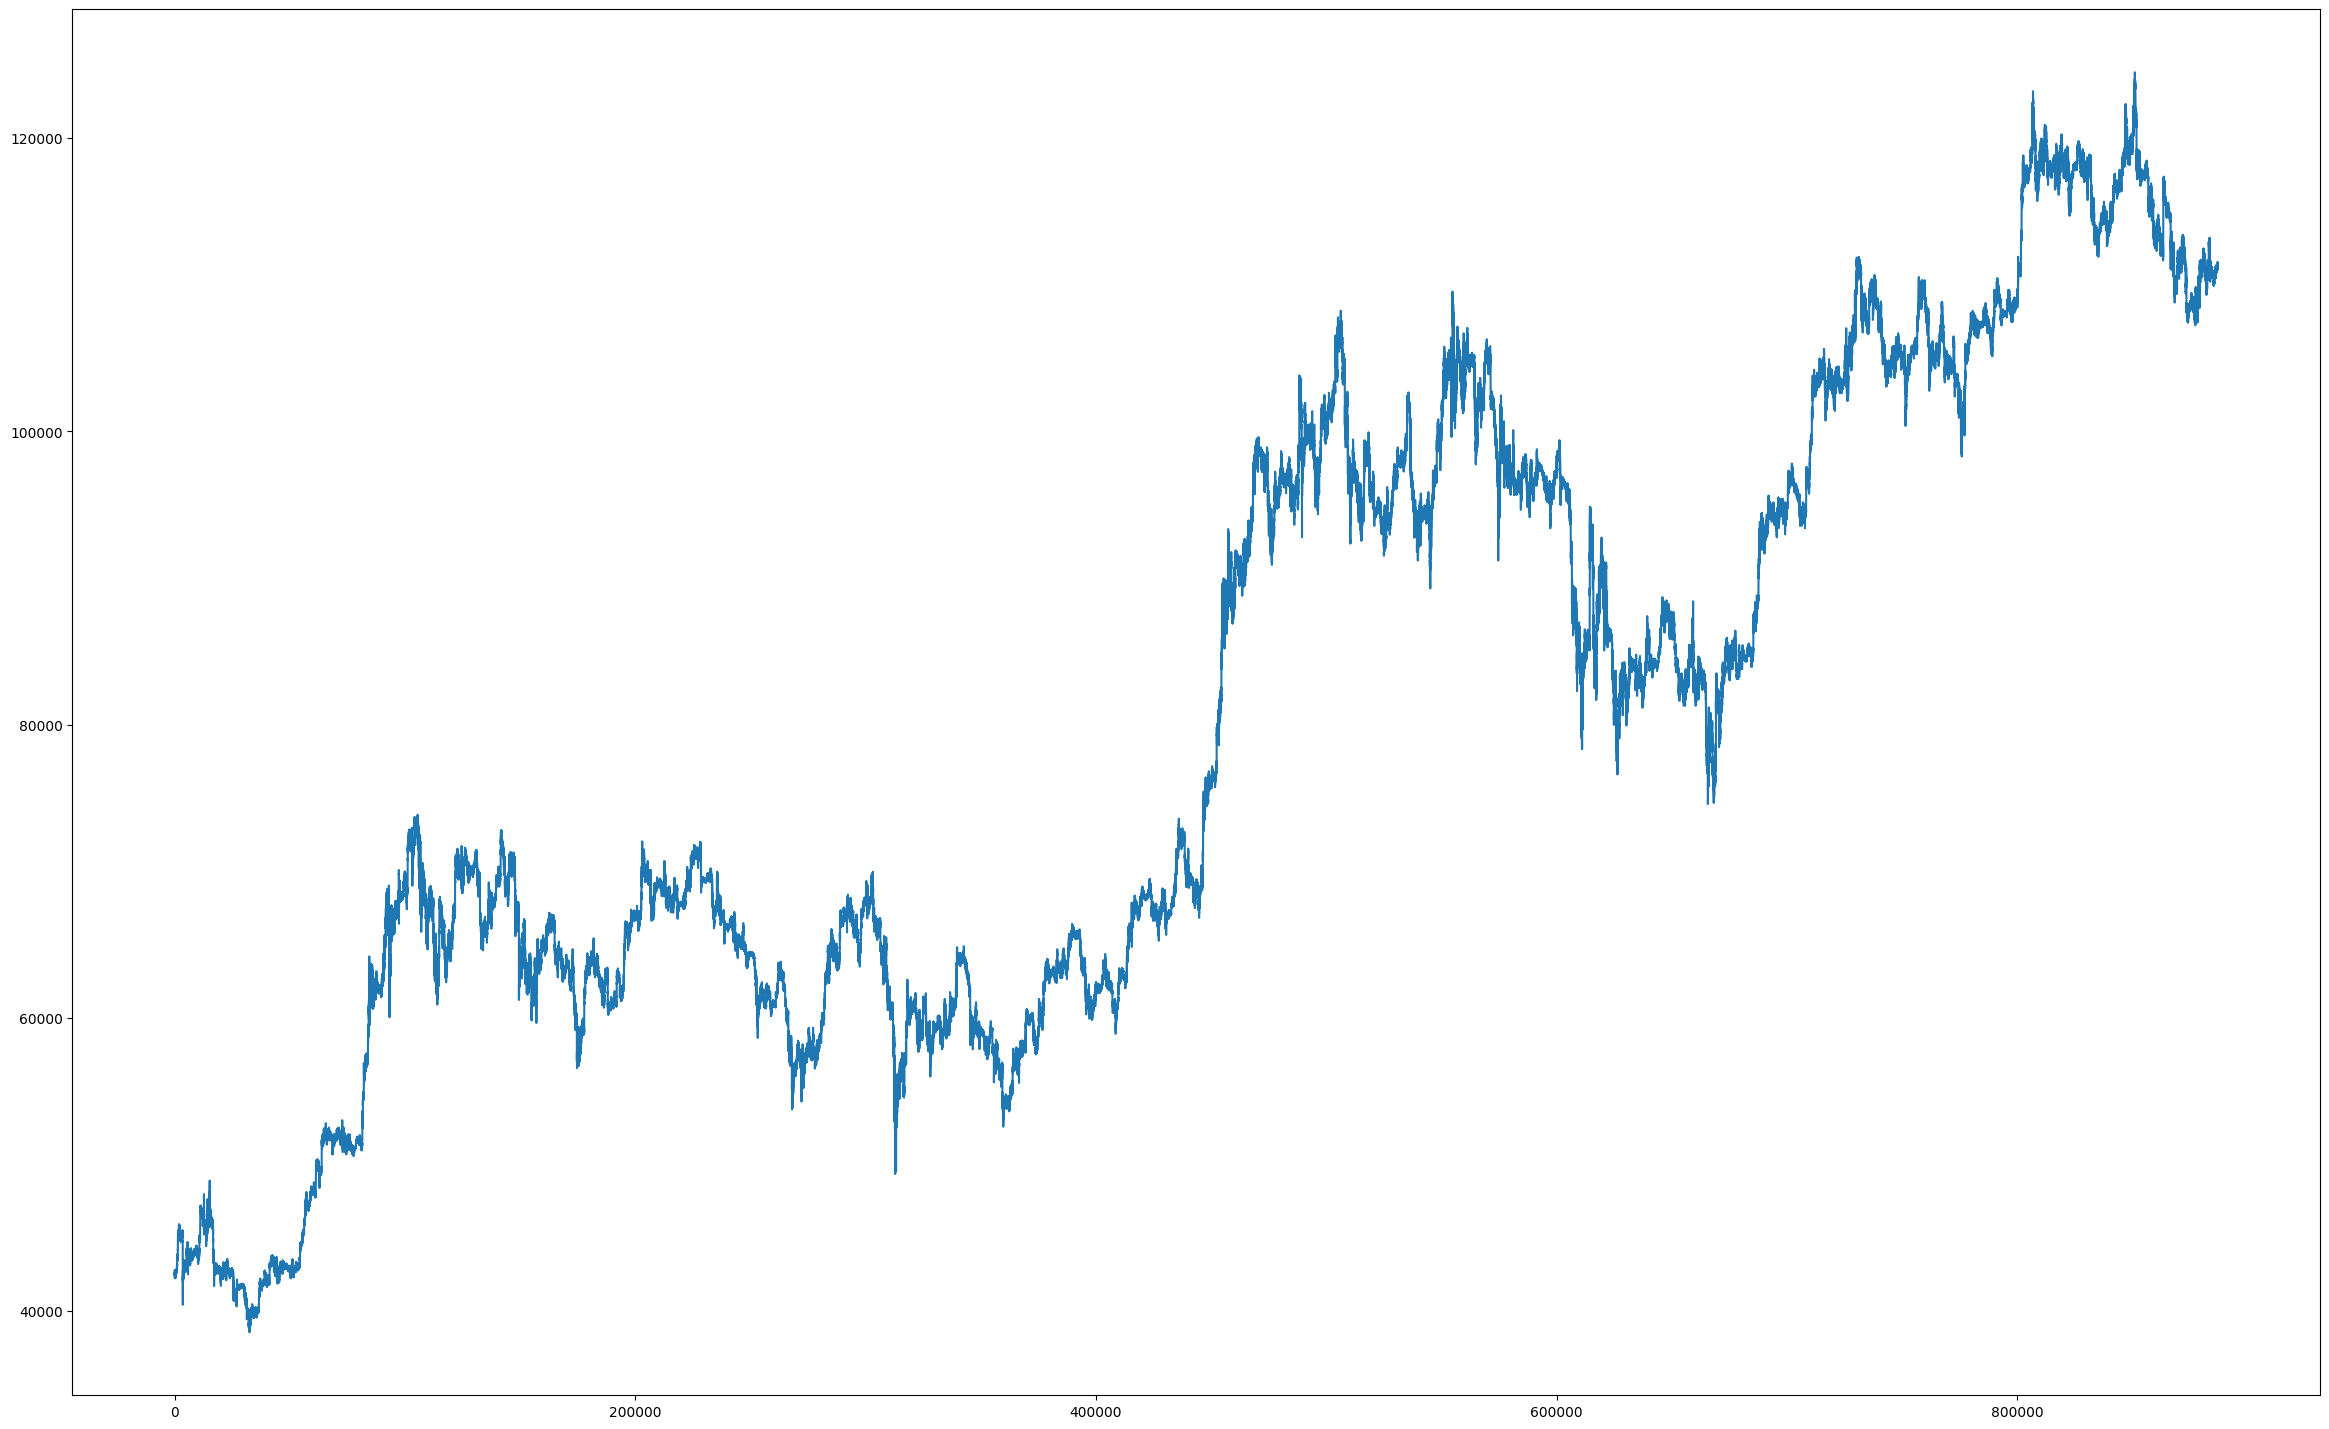

In [4]:
plt.plot(hlcv[:,2])

In [5]:
results = {(0.01632, 1.518, 51.54, 0.02986, 0.02407, 0.005983, 0.01054, 1.3, 0.7, 10): None}
eligible = {}

In [6]:
len(eligible)

0

In [7]:
def perform_backtest(hlcvs, key):
    (
        initial_qty_pct,
        double_down_factor,
        wallet_exposure_limit,
        trailing_threshold_pct_profit,
        trailing_threshold_pct_loss,
        trailing_retracement_pct_profit,
        trailing_retracement_pct_loss,
        adx_scale_higher_width,
        adx_scale_lower_width,
        max_flips_per_cycle,
    ) = key
    fee_rate = 0.00055
    fills, equities, coin_indices = pbr.backtest_trailing_flip_multi(
        hlcvs,         # shape: (n_coins, n_bars, 4)
        initial_qty_pct,
        double_down_factor,
        wallet_exposure_limit,
        trailing_threshold_pct_profit,
        trailing_retracement_pct_profit,
        trailing_threshold_pct_loss,
        trailing_retracement_pct_loss,
        fee_rate,
        adx_scale_higher_width,
        adx_scale_lower_width,
        int(max_flips_per_cycle),  # Ensure int
    )
    fdf = pd.DataFrame(
        fills,
        columns=[
            "bar", "coin_idx", "pnl", "fee_paid", "balance", "qty", "price",
            "psize", "pprice", "upnl", "type"
        ]
    )
    fdf.set_index(["bar", "coin_idx"], inplace=True)

    edf = pd.Series(equities)
    coin_cycle = pd.Series(coin_indices)
    fdf.loc[:,'wallet_exposure'] = fdf.psize.abs() * fdf.pprice / fdf.balance
    fdf.loc[:,'equity'] = fdf.balance + fdf.upnl
    drawdowns = calc_drawdowns(edf)
    drawdown_worst = abs(drawdowns.min())
    gain = edf.iloc[-1] / edf.iloc[0]
    n_days = len(edf) / 60 / 24
    adg = gain ** (1 / n_days) - 1 if gain > 0.0 else gain
    return {'drawdown_worst': drawdown_worst, 'gain': gain}

In [ ]:
begin_harmony_search = 20
harmony_memory_size = 20
limit_drawdown_worst = 0.50
n_iters = 40000
max_flips_upper_bound = 6
max_flips_lower_bound = 1

for k in results:
    if results[k] is None:
        results[k] = perform_backtest(hlcvs, k)
        print('backtested', k, results[k])
        
eligible = {k: v for k, v in results.items() if v and v['drawdown_worst'] < limit_drawdown_worst}
for z in range(n_iters):
    if len(eligible) > begin_harmony_search:
        mode = 'harmony_search'
        resfs = sorted(eligible.items(), key=lambda x: x[1]['gain'])[-harmony_memory_size:]
        candidate = []
        for i in range(len(resfs[0][0])):
            vals = [resfs[k][0][i] for k in range(len(resfs))]
            candidate.append((np.random.choice(vals) + np.random.uniform(-0.000001, 0.000001)) * np.random.uniform(0.9, 1.1))
        # Clamp max_flips_per_cycle to wanted bounds
        candidate[-1] = int(np.clip(round(candidate[-1]), max_flips_lower_bound, max_flips_upper_bound))
    else:
        mode = 'random'
        initial_qty_pct = np.random.uniform(0.01, 1.0)
        double_down_factor = np.random.uniform(1.1, 3.0)
        wallet_exposure_limit = np.random.uniform(10.0, 100.0)
        trailing_threshold_pct_profit = np.random.uniform(0.01, 0.03)
        trailing_threshold_pct_loss = np.random.uniform(0.01, 0.03)
        trailing_retracement_pct_profit = np.random.uniform(0.00001, 0.01)
        trailing_retracement_pct_loss = np.random.uniform(0.00001, 0.01)
        adx_scale_higher_width = np.random.uniform(0.0, 3.0)
        adx_scale_lower_width = np.random.uniform(0.0, 3.0)
        max_flips_per_cycle = int(np.random.randint(max_flips_lower_bound, max_flips_upper_bound + 1))

        candidate = [
            initial_qty_pct,
            double_down_factor,
            wallet_exposure_limit,
            trailing_threshold_pct_profit,
            trailing_threshold_pct_loss,
            trailing_retracement_pct_profit,
            trailing_retracement_pct_loss,
            adx_scale_higher_width,
            adx_scale_lower_width,
            max_flips_per_cycle,
        ]
        
    key = (
        pbr.round_dynamic(candidate[0], 4),
        pbr.round_dynamic(candidate[1], 4),
        pbr.round_dynamic(candidate[2], 4),
        pbr.round_dynamic(candidate[3], 4),
        pbr.round_dynamic(candidate[4], 4),
        pbr.round_dynamic(candidate[5], 4),
        pbr.round_dynamic(candidate[6], 4),
        pbr.round_dynamic(candidate[7], 4),
        pbr.round_dynamic(candidate[8], 4),
        int(candidate[9]),  # Ensure int
    )
    if key in results:
        continue
    result = perform_backtest(hlcvs, key)
    results[key] = result
    if result['drawdown_worst'] < limit_drawdown_worst:
        eligible[key] = result
        print(z, len(eligible), mode, key, eligible[key])
        

backtested (0.01632, 1.518, 51.54, 0.02986, 0.02407, 0.005983, 0.01054, 1.3, 0.7, 10) {'drawdown_worst': 0.000854168277260779, 'gain': 0.9837101933262055}
0 2 random (0.7403, 2.129, 50.63, 0.01579, 0.02951, 0.001092, 0.003499, 1.107, 2.181, 1) {'drawdown_worst': 0.12749186644070148, 'gain': 0.26106961515869825}
1 3 random (0.0806, 1.754, 52.07, 0.0246, 0.01671, 0.005457, 0.007679, 2.095, 1.854, 3) {'drawdown_worst': 0.00449639567738807, 'gain': 0.919549116549765}
2 4 random (0.7354, 1.789, 73.68, 0.01469, 0.02259, 0.007362, 0.008303, 0.1442, 0.1592, 2) {'drawdown_worst': 0.12471469157123297, 'gain': 0.2659605497605115}
3 5 random (0.4735, 2.107, 75.21, 0.01024, 0.02782, 0.00202, 0.004448, 2.622, 2.107, 6) {'drawdown_worst': 0.04422003748413024, 'gain': 0.5273760134778381}
4 6 random (0.5991, 1.497, 77.56, 0.02624, 0.01442, 0.00453, 0.007199, 1.764, 0.9271, 2) {'drawdown_worst': 0.07131703257686245, 'gain': 0.40200838368442}
5 7 random (0.1995, 2.029, 38.7, 0.02468, 0.02032, 0.002638, 0

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7394d670e110>>
Traceback (most recent call last):
  File "/home/waffle/Desktop/passivbot/venv/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


11534 11535 harmony_search (-1.707e-05, 0.1298, 0.1536, 0.0021, 0.03429, 0.0002892, 0.00254, 0.05632, 0.3823, 2) {'drawdown_worst': 0.0, 'gain': 1.0}
11535 11536 harmony_search (-1.988e-05, 0.1358, 0.1401, 0.003244, 0.03869, 0.0002421, 0.003357, 0.0439, 0.2933, 2) {'drawdown_worst': 0.0, 'gain': 1.0}
11536 11537 harmony_search (-1.88e-05, 0.1027, 0.1465, 0.003074, 0.03413, 0.0002854, 0.002551, 0.0562, 0.3326, 2) {'drawdown_worst': 0.0, 'gain': 1.0}
11537 11538 harmony_search (-2.104e-05, 0.1254, 0.1477, 0.002259, 0.0349, 0.0002813, 0.002549, 0.04944, 0.3131, 2) {'drawdown_worst': 0.0, 'gain': 1.0}
11538 11539 harmony_search (-1.938e-05, 0.1274, 0.1809, 0.003336, 0.03747, 0.0002906, 0.002744, 0.06331, 0.2105, 2) {'drawdown_worst': 0.0, 'gain': 1.0}
11539 11540 harmony_search (-2.096e-05, 0.1241, 0.1401, 0.00259, 0.0356, 0.0003024, 0.003309, 0.05279, 0.2264, 2) {'drawdown_worst': 0.0, 'gain': 1.0}
11540 11541 harmony_search (-1.508e-05, 0.0952, 0.1608, 0.002609, 0.03471, 0.0001724, 0.003

In [ ]:
resf = {k: v for k, v in results.items() if v['drawdown_worst'] < limit_drawdown_worst}
resfs = sorted(resf.items(), key=lambda x: x[1]['gain'])[-harmony_memory_size:]
resfs

In [ ]:
if not resfs:
    print("No eligible candidates found.")
    # Skip further processing
    raise ValueError("No eligible candidates found. Adjust parameters or increase iterations.")

candidate = resfs[-1][0]
fee_rate = 0.00055
nitial_qty_pct, double_down_factor, wallet_exposure_limit, trailing_threshold_pct_profit, trailing_threshold_pct_loss, trailing_retracement_pct_profit, trailing_retracement_pct_loss, adx_scale_higher_width, adx_scale_lower_width, max_flips_per_cycle = candidate
fills, equities = pbr.backtest_trailing_flip_multi(
    hlcv,
    initial_qty_pct,
    double_down_factor,
    wallet_exposure_limit,
    trailing_threshold_pct_profit,
    trailing_retracement_pct_profit,
    trailing_threshold_pct_loss,
    trailing_retracement_pct_loss,
    fee_rate,
    adx_scale_higher_width,
    adx_scale_lower_width,
    int(max_flips_per_cycle),  # Ensure int
)
fdf = pd.DataFrame(fills, columns=["index", "pnl", "fee_paid", "balance", "qty", "price", "psize", "pprice", "upnl", "type"]).set_index('index')
edf = pd.Series(equities)
fdf.loc[:,'wallet_exposure'] = fdf.psize.abs() * fdf.pprice / fdf.balance
fdf.loc[:,'equity'] = fdf.balance + fdf.upnl
drawdowns = calc_drawdowns(edf)
drawdown_worst = abs(drawdowns.min())
gain = edf.iloc[-1] / edf.iloc[0]
n_days = len(edf) / 60 / 24
adg = gain ** (1 / n_days) - 1
print('drawdown_worst', drawdown_worst)
print('n_days', n_days)
print('n fills', len(fdf))
print('adg', adg)
print('gain', gain)
print('WE max', fdf.wallet_exposure.max())

param_names = [
    "initial_qty_pct",
    "double_down_factor",
    "wallet_exposure_limit",
    "trailing_threshold_pct_profit",
    "trailing_threshold_pct_loss",
    "trailing_retracement_pct_profit",
    "trailing_retracement_pct_loss",
    "adx_scale_higher_width",
    "adx_scale_lower_width",
    "max_flips_per_cycle",
]
print()
for name, value in zip(param_names, candidate):
    print(f"{name}: {value}")

In [ ]:
edf.plot(logy=True)

In [ ]:
edf.plot(logy=False)

In [ ]:
cost_pct = (fdf.qty.abs() * fdf.price) / fdf.balance
cost_pct.groupby(cost_pct.index // 1440).sum().mean()

In [ ]:
fdf.iloc[:60]

In [ ]:
exchange_min_order = 5

candidate = resfs[-1][0]
fee_rate = 0.00055
initial_qty_pct, double_down_factor, wallet_exposure_limit, trailing_threshold_pct_profit, trailing_threshold_pct_loss, trailing_retracement_pct_profit, trailing_retracement_pct_loss, adx_scale_higher_width, adx_scale_lower_width, max_flips_per_cycle = candidate

# Convert wallet_exposure_limit from percentage to decimal
wallet_exposure_limit /= 100 

# Calculate the total required balance for max flips
total_order_size = 0
for i in range(max_flips_per_cycle):
    total_order_size += exchange_min_order * (double_down_factor ** i)

# Adjust for wallet exposure limit
required_balance = total_order_size / wallet_exposure_limit

print(f"Minimum starting balance needed: {required_balance:.2f}")

In [ ]:
fdf.sort_values('wallet_exposure')

In [ ]:
i = 607126
n = 7000
fdfc = fdf.loc[i-n:i+n]
buys = fdfc[fdfc.qty > 0.0]
sells = fdfc[fdfc.qty < 0.0]
pd.DataFrame(hlcv[:,2]).loc[i-n:i+n].plot()
buys.price.plot(style='bo')
sells.price.plot(style='ro')

In [ ]:
fdfc

In [ ]:
edf.loc[fdfc.index[0]:fdfc.index[-1]].plot()

In [ ]:
fdf.sort_values('wallet_exposure').iloc[-10:]

In [ ]:
for coin_idx in fdf.index.get_level_values("coin_idx").unique():
    coin_fills = fdf.xs(coin_idx, level="coin_idx")
    coin_name = coins[coin_idx] if 'coins' in locals() else str(coin_idx)
    plt.figure()
    coin_fills["balance"].plot(title=f"Balance Over Time ({coin_name})")
    plt.xlabel("bar")
    plt.ylabel("balance")
    plt.show()